**Trabajo Unidad I**

Carrera: Ingeniería Civil Industrial

Asignatura: MACHINE LEARNING | eINGT1029-01

Profesor: Franco Mansilla

Fecha de envío: 24-08-2026

Nombre(s) de estudiante(s):
•	Yorka Castillo
•	Melanie Olguin
•	Ignacio Rivera
•	Paulina Soto


**Introducción**

El aprendizaje automático, más conocido como **Machine Learning**, hoy en día deja de ser ciencia ficción para convertirse en una herramienta apliamente utilizada, con un objetivo principal que busca básicamente enseñarle a un computador a encontrar patrones en los datos que pueden ser predicciones para una buena toma de decisiones.

Bajo este contexto, se desarrolla un flujo de trabajo, pipeline, de análitica de datos robustos y reproducibles con el dataset del Titanic, provisto por Kaggle. El desafío es utilizar la información de los pasajeros, tales como, edad, sexo o clase en la que viajaban, para predecir quién sobrevivió al naufragio y quién lamentablemente no lo logra.

En primera instancia y con el fin de garantizar un enfoque estructurado iniciamos la evaluación de tres metodologías estándares en la industria (CRISP-DM, KDD y SEMMA), con las cuales se analizan ventajas y limitaciones para una mejor organización del proyecto. Posteriormente, se ejecuta una exploración de datos y corrección de errores, para luego y como finalización de este proyecto concretar un diseño estratégico de la serparación de datos empaquetado en un código automatizado, pipeline, asegurando que los datos se dividan de forma justa y representativa, para ser puesto a prueba ante cualquier modelo en el futuro.




**Describir Framework**

Este trabajo tiene como objetivo desarrollar un pipeline reproducible de Data Science utilizando el dataset Titanic, disponible en Kaggle.

El problema corresponde a una tarea de clasificación supervisada, su objetivo es utilizar las características de los diferente pasajeros para predecir si una persona sobrevivió o no al naufragio.

La variable objetivo corresponde a:

Survived = 0: pasajero no sobrevivió.
Survived = 1: pasajero sobrevivió.

El pipeline considera las siguientes etapas:

Análisis de distintos frameworks de analítica de datos.
Exploración inicial del dataset.
Evaluación de la calidad de los datos.
Identificación y tratamiento de datos atípicos.
Identificación y tratamiento de valores faltantes.
Comparación de tres métodos de separación de datos.
Selección y aplicación del método más apropiado.
Preparación de un pipeline reproducible.
Almacenamiento del desarrollo en GitHub.

Este trabajo analiza tres metodologías: CRISP-DM, KDD y SEMMA.

**1- CRISP-DM**

CRISP-DM significa Cross Industry Standard Process for Data Mining.

Es una metodología que ordena un proyecto en seis etapas:

Analizar el negocio.
Comprensión de los datos.
Preparación de los datos.
Modelamiento.
Evaluación.
Implementación.

**Alcance**

Logra abordar un proyecto en su totalidad, identificando el problema y terminar en el analisis de sus resultados.

Se utiliza en distintas industrias, sin depender del lenguaje de programación.

**Ventajas**

Considera el problema de negocio como el análisis técnico.
Es independiente de las herramientas utilizadas e iterativo, lo que permite regresar a etapas anteriores.
Su utilizacion ayuda a la documentación y reproducibilidad.

**Limitaciones**

Fue creado antes de la aparición de prácticas modernas de MLOps.
No especifica detalladamente cómo desplegar y monitorear modelos.
En ocasiones requiere adaptaciones en metodologías ágiles.

**2- KDD**

KDD significa Knowledge Discovery in Databases.

Tiene como objetivo analizar información y patrones dentro de los datos.

Sus etapas principales son:

Selección.
Preprocesamiento.
Transformación.
Minería de datos.
Interpretación y evaluación.

**Alcance**

KDD se enfoca a la extracción de conocimiento sobre datos existentes.

**Ventajas**

Tiende al descubrimiento de patrones.
Existe una gran importancia en la limpieza de datos.
Se puede utilizar en grandes volúmenes de información.

**Limitaciones**

No se enfoca en la comprensión del negocio.
No desarrolla ampliamente la fase de implementación.
Se centra en el análisis técnico.

**3- SEMMA**

SEMMA fue desarrollada por SAS y su nombre representa:

Sample: seleccionar una muestra.
Explore: explorar los datos.
Modify: transformar los datos.
Model: construir modelos.
Assess: evaluar los resultados.

**Alcance**

SEMMA se enfoca en el procesamiento, modelamiento y evaluación de los datos.

**Ventajas**

Estructura sencilla.
Fuerte enfoque estadístico.
Facilita la experimentación con modelos.
Enfocada en proyectos predictivos.

**Limitaciones**

Tiene menor enfoque en la comprensión inicial del problema.
Asociada al entorno SAS.
No considera de forma detallada la implementación del modelo.

In [92]:
#1. Carga de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [93]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
df = pd.read_csv('/content/drive/MyDrive/train 1.csv')

df.head()

print("Dataset cargado correctamente")
print("Dimensiones:", df.shape)

display(df.head())

Dataset cargado correctamente
Dimensiones: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [95]:
#2. Información de datos

print("DIMENSIONES")
print(df.shape)

print("\nCOLUMNAS")
print(df.columns.tolist())

print("\nPRIMEROS REGISTROS")
display(df.head())

print("\nINFORMACIÓN DEL DATASET")
df.info()

print("\nESTADÍSTICAS DESCRIPTIVAS")
display(df.describe())


DIMENSIONES
(891, 12)

COLUMNAS
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

PRIMEROS REGISTROS


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

ESTADÍSTICAS DESCRIPTIVAS


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [96]:
display(df.describe(include="object"))

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [97]:
#3. Variable Objetiva

print("Cantidad por clase:")
print(df["Survived"].value_counts())

print("\nPorcentaje por clase:")
print(df["Survived"].value_counts(normalize=True) * 100)

Cantidad por clase:
Survived
0    549
1    342
Name: count, dtype: int64

Porcentaje por clase:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


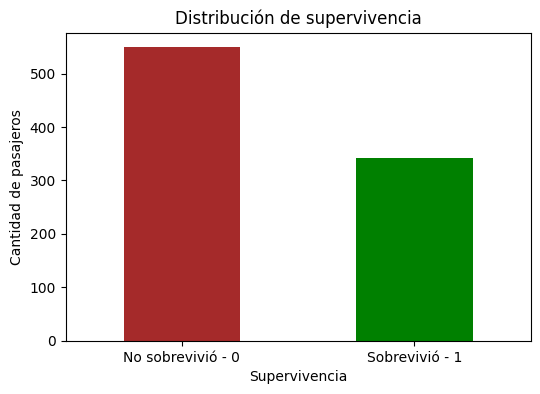

In [98]:
plt.figure(figsize=(6, 4))

df["Survived"].value_counts().sort_index().plot(
    kind="bar",
    color=["brown", "green"]
)

plt.title("Distribución de supervivencia")
plt.xlabel("Supervivencia")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(
    ticks=[0, 1],
    labels=["No sobrevivió - 0", "Sobrevivió - 1"],
    rotation=0
)

plt.show()

In [99]:
#4. Supervivencia según sexo

tabla_sexo = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

display(tabla_sexo)

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


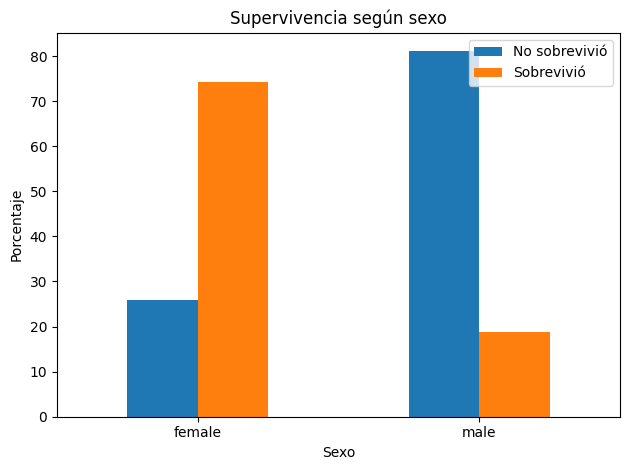

In [100]:
tabla_sexo.plot(kind="bar")

plt.title("Supervivencia según sexo")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(["No sobrevivió", "Sobrevivió"])
plt.tight_layout()
plt.show()

In [101]:
#5. Supervivencia según tipo de clase

tabla_clase = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

display(tabla_clase)

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


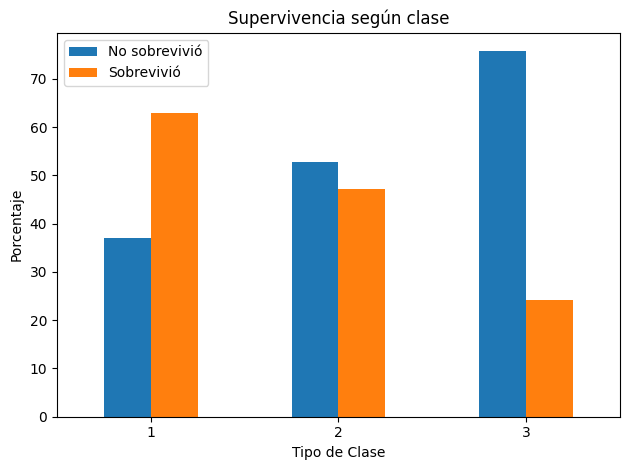

In [102]:
tabla_clase.plot(kind="bar")

plt.title("Supervivencia según clase")
plt.xlabel("Tipo de Clase")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(["No sobrevivió", "Sobrevivió"])
plt.tight_layout()
plt.show()

In [103]:
#6. Identificar valores faltantes

missing = pd.DataFrame({
    "Cantidad": df.isnull().sum(),
    "Porcentaje": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(missing.sort_values(
    by="Cantidad",
    ascending=False
))

,Cantidad,Porcentaje
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


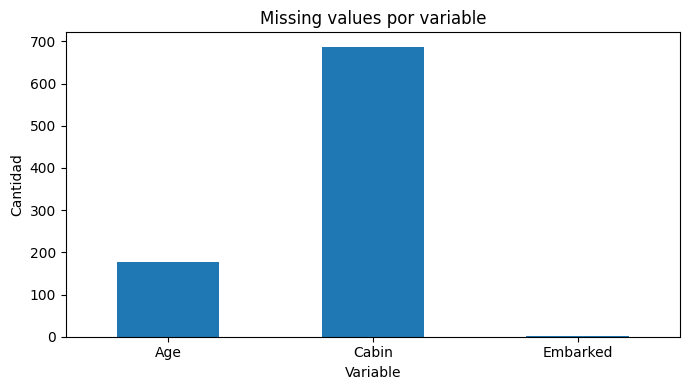

In [104]:
missing_plot = missing[missing["Cantidad"] > 0]

plt.figure(figsize=(7, 4))

missing_plot["Cantidad"].plot(kind="bar")

plt.title("Missing values por variable")
plt.xlabel("Variable")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [105]:
#7. Limpiar codigos - Revisar duplicados

print("Filas duplicadas:")
print(df.duplicated().sum())

df = df.drop_duplicates()

Filas duplicadas:
0


In [106]:
#8. Explorar Edad

print(df["Age"].describe())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


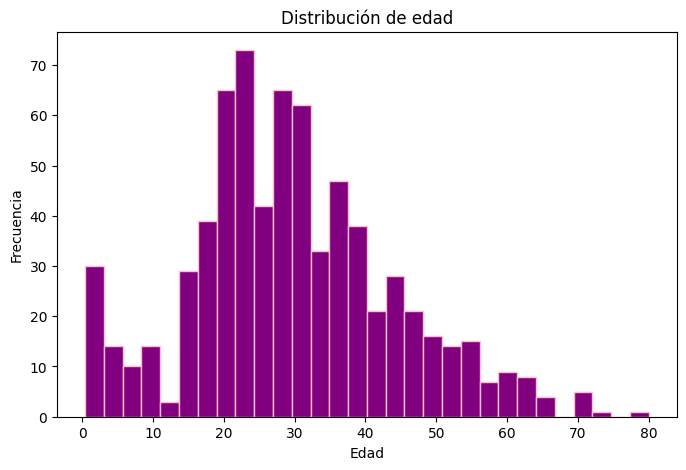

In [107]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Age"].dropna(),
    bins=30,
    color="purple",
    edgecolor="pink",
    linewidth=1
)

plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

In [108]:
#9. Detectar outliers mediante IQR

def detectar_outliers_iqr(data, columna):

    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = data[
        (data[columna] < limite_inferior) |
        (data[columna] > limite_superior)
    ]

    print("Variable:", columna)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Límite inferior:", limite_inferior)
    print("Límite superior:", limite_superior)
    print("Cantidad de outliers:", len(outliers))

    return outliers

In [109]:
#Variable Edad

outliers_age = detectar_outliers_iqr(
    df,
    "Age"
)

Variable: Age
Q1: 20.125
Q3: 38.0
IQR: 17.875
Límite inferior: -6.6875
Límite superior: 64.8125
Cantidad de outliers: 11


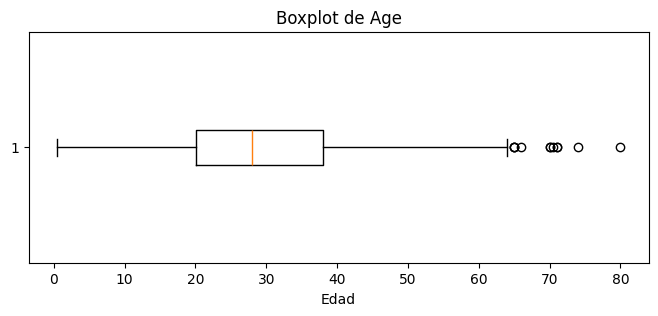

In [110]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    df["Age"].dropna(),
    vert=False
)

plt.title("Boxplot de Age")
plt.xlabel("Edad")
plt.show()

In [111]:
#Variable Tarifa

outliers_fare = detectar_outliers_iqr(
    df,
    "Fare"
)

Variable: Fare
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Límite inferior: -26.724
Límite superior: 65.6344
Cantidad de outliers: 116


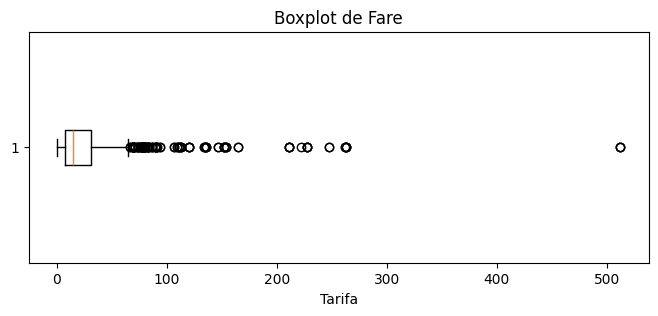

In [112]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    df["Fare"].dropna(),
    vert=False
)

plt.title("Boxplot de Fare")
plt.xlabel("Tarifa")
plt.show()

In [113]:
df_clean = df.copy()

In [114]:
#Mediana de Edad

mediana_age = df_clean["Age"].median()

print("Mediana Age:", mediana_age)

df_clean["Age"] = (
    df_clean["Age"]
    .fillna(mediana_age)
)

Mediana Age: 28.0


In [115]:
# Moda Embarque

moda_embarked = df_clean["Embarked"].mode()[0]

print("Moda Embarked:", moda_embarked)

df_clean["Embarked"] = (
    df_clean["Embarked"]
    .fillna(moda_embarked)
)

# Comprobar que ya no quedan valores faltantes
print("Missing values en Embarked:", df_clean["Embarked"].isnull().sum())

Moda Embarked: S
Missing values en Embarked: 0


In [116]:
df_clean = df_clean.drop(
    columns=["Cabin"]
)

In [117]:
print(df_clean.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [118]:
#13. Tratamiento de Fare

df_clean["Fare_log"] = np.log1p(
    df_clean["Fare"]
)

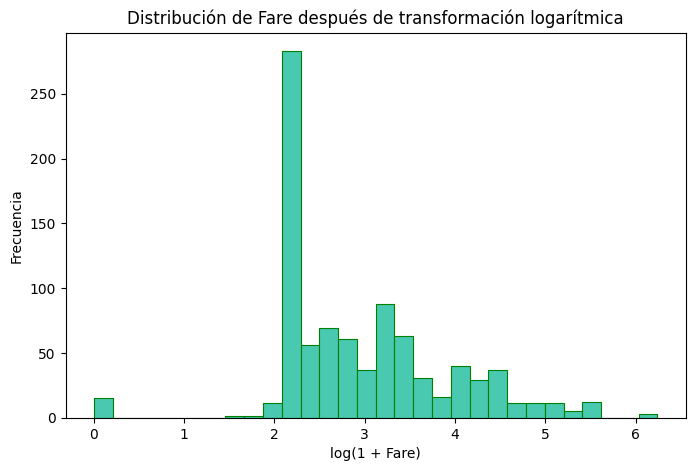

In [119]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["Fare_log"],
    bins=30,
    color="#48C9B0",
    edgecolor="green",
    linewidth=0.8
)

plt.title("Distribución de Fare después de transformación logarítmica")
plt.xlabel("log(1 + Fare)")
plt.ylabel("Frecuencia")

plt.show()

In [120]:
#14. Eliminar variables que no utilizaremos

df_model = df_clean.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Fare"
    ]
)

display(df_model.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,Fare_log
0,0,3,male,22.0,1,0,S,2.110213
1,1,1,female,38.0,1,0,C,4.280593
2,1,3,female,26.0,0,0,S,2.188856
3,1,1,female,35.0,1,0,S,3.990834
4,0,3,male,35.0,0,0,S,2.202765


In [121]:
#15. Codificación de variables categóricas (convertir variables Sex y Embarked en números)

df_model = pd.get_dummies(
    df_model,
    columns=[
        "Sex",
        "Embarked"
    ],
    drop_first=True,
    dtype=int
)

display(df_model.head())

,Survived,Pclass,Age,SibSp,Parch,Fare_log,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,2.110213,1,0,1
1,1,1,38.0,1,0,4.280593,0,0,0
2,1,3,26.0,0,0,2.188856,0,0,1
3,1,1,35.0,1,0,3.990834,0,0,1
4,0,3,35.0,0,0,2.202765,1,0,1


In [122]:
#16. Separar X e y

X = df_model.drop(
    columns=["Survived"]
)

y = df_model["Survived"]

print("Variables predictoras:")
print(X.columns)

print("\nVariable objetivo:")
print(y.name)

Variables predictoras:
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare_log', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

Variable objetivo:
Survived


In [123]:
#17. Método 1: Hold-Out aleatorio

from sklearn.model_selection import train_test_split

X_train_random, X_temp_random, y_train_random, y_temp_random = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42
    )
)

X_val_random, X_test_random, y_val_random, y_test_random = (
    train_test_split(
        X_temp_random,
        y_temp_random,
        test_size=0.50,
        random_state=42
    )
)

print("TRAIN:", len(X_train_random))
print("VALIDATION:", len(X_val_random))
print("TEST:", len(X_test_random))

TRAIN: 623
VALIDATION: 134
TEST: 134


In [124]:
#18. Método 2: Hold-Out estratificado

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (623, 8)
Validation: (134, 8)
Test: (134, 8)


In [125]:
#19. Comprobar la estratificación

def mostrar_distribucion(nombre, y_data):

    print("\n", nombre)

    print(
        y_data
        .value_counts(normalize=True)
        .sort_index()
        .round(3)
    )

mostrar_distribucion(
    "Dataset completo",
    y
)

mostrar_distribucion(
    "Train",
    y_train
)

mostrar_distribucion(
    "Validation",
    y_val
)

mostrar_distribucion(
    "Test",
    y_test
)


 Dataset completo
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

 Train
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

 Validation
Survived
0    0.612
1    0.388
Name: proportion, dtype: float64

 Test
Survived
0    0.619
1    0.381
Name: proportion, dtype: float64


In [126]:
#20. Método 3: Stratified K-Fold

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_index, val_index) in enumerate(
    skf.split(X, y),
    start=1
):

    X_train_fold = X.iloc[train_index]
    X_val_fold = X.iloc[val_index]

    y_train_fold = y.iloc[train_index]
    y_val_fold = y.iloc[val_index]

    print(
        f"Fold {fold}: "
        f"Train = {len(train_index)}, "
        f"Validation = {len(val_index)}"
    )

Fold 1: Train = 712, Validation = 179
Fold 2: Train = 713, Validation = 178
Fold 3: Train = 713, Validation = 178
Fold 4: Train = 713, Validation = 178
Fold 5: Train = 713, Validation = 178


In [127]:
#21. Tabla comparativa de los tres métodos

comparacion = pd.DataFrame({
    "Método": [
        "Hold-Out aleatorio",
        "Hold-Out estratificado",
        "Stratified K-Fold"
    ],

    "Mantiene proporción clases": [
        "No necesariamente",
        "Sí",
        "Sí"
    ],

    "Costo computacional": [
        "Bajo",
        "Bajo",
        "Mayor"
    ],

    "Ventaja principal": [
        "Simple y rápido",
        "Muestras representativas",
        "Evaluación más robusta"
    ],

    "Desventaja principal": [
        "Puede desbalancear las clases",
        "Depende de una sola división",
        "Mayor tiempo de procesamiento"
    ]
})

display(comparacion)

,Método,Mantiene proporción clases,Costo computacional,Ventaja principal,Desventaja principal
0,Hold-Out aleatorio,No necesariamente,Bajo,Simple y rápido,Puede desbalancear las clases
1,Hold-Out estratificado,Sí,Bajo,Muestras representativas,Depende de una sola división
2,Stratified K-Fold,Sí,Mayor,Evaluación más robusta,Mayor tiempo de procesamiento


In [128]:
#22. Pipeline reproducible

def limpiar_titanic(data):

    df_clean = data.copy()

    # Eliminar duplicados
    df_clean = df_clean.drop_duplicates()

    # Crear variable de disponibilidad de cabina
    df_clean["HasCabin"] = (
        df_clean["Cabin"]
        .notna()
        .astype(int)
    )

    # Imputación de Age
    df_clean["Age"] = (
        df_clean["Age"]
        .fillna(
            df_clean["Age"].median()
        )
    )

    # Imputación de Embarked
    df_clean["Embarked"] = (
        df_clean["Embarked"]
        .fillna(
            df_clean["Embarked"].mode()[0]
        )
    )

    # Transformar Fare
    df_clean["Fare_log"] = np.log1p(
        df_clean["Fare"]
    )

    # Eliminar variables no utilizadas
    df_clean = df_clean.drop(
        columns=[
            "PassengerId",
            "Name",
            "Ticket",
            "Cabin",
            "Fare"
        ]
    )

    # One-Hot Encoding
    df_clean = pd.get_dummies(
        df_clean,
        columns=[
            "Sex",
            "Embarked"
        ],
        drop_first=True,
        dtype=int
    )

    return df_clean

In [129]:
datos_originales = pd.read_csv(
    "/content/drive/MyDrive/train 1.csv"
)

datos_limpios = limpiar_titanic(
    datos_originales
)

display(datos_limpios.head())

print("\nMissing values:")
print(datos_limpios.isnull().sum())

,Survived,Pclass,Age,SibSp,Parch,HasCabin,Fare_log,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,0,2.110213,1,0,1
1,1,1,38.0,1,0,1,4.280593,0,0,0
2,1,3,26.0,0,0,0,2.188856,0,0,1
3,1,1,35.0,1,0,1,3.990834,0,0,1
4,0,3,35.0,0,0,0,2.202765,1,0,1



Missing values:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
HasCabin      0
Fare_log      0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [130]:
#23. Función split

def split_estratificado(
    data,
    target="Survived",
    random_state=42
):

    X = data.drop(
        columns=[target]
    )

    y = data[target]

    X_train, X_temp, y_train, y_temp = (
        train_test_split(
            X,
            y,
            test_size=0.30,
            random_state=random_state,
            stratify=y
        )
    )

    X_val, X_test, y_val, y_test = (
        train_test_split(
            X_temp,
            y_temp,
            test_size=0.50,
            random_state=random_state,
            stratify=y_temp
        )
    )

    return (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test
    )

In [131]:
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = split_estratificado(
    datos_limpios
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (623, 9)
Validation: (134, 9)
Test: (134, 9)


In [132]:
# PIPELINE FINAL TITANIC

from sklearn.model_selection import train_test_split


# 1. Carga
df = pd.read_csv(
    "/content/drive/MyDrive/train 1.csv"
)


# 2. Limpieza
df_clean = limpiar_titanic(df)


# 3. Calidad final
print("Missing values:")
print(df_clean.isnull().sum())


# 4. Separación
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = split_estratificado(
    df_clean
)


# 5. Resultados
print("\n---------------------------")
print("RESULTADO DEL PIPELINE")
print("---------------------------")

print(
    "Dataset original:",
    df.shape
)

print(
    "Dataset procesado:",
    df_clean.shape
)

print(
    "Entrenamiento:",
    X_train.shape
)

print(
    "Validación:",
    X_val.shape
)

print(
    "Test:",
    X_test.shape
)

print(
    "Duplicados en dataset original:",
    df.duplicated().sum()
)

print(
    "Filas idénticas después de seleccionar variables:",
    df_clean.duplicated().sum()
)

Missing values:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
HasCabin      0
Fare_log      0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

---------------------------
RESULTADO DEL PIPELINE
---------------------------
Dataset original: (891, 12)
Dataset procesado: (891, 10)
Entrenamiento: (623, 9)
Validación: (134, 9)
Test: (134, 9)
Duplicados en dataset original: 0
Filas idénticas después de seleccionar variables: 111


Método seleccionado

Se selecciona Hold-Out estratificado para realizar la separación principal en entrenamiento, validación y test.

Esto se debe a que el problema corresponde a clasificación binaria y la variable Survived tiene una distribución aproximada de:

61,6 % clase 0.
38,4 % clase 1.

Al estratificar, se mantiene una proporción semejante en las tres muestras.

La distribución utilizada será:

70 % entrenamiento.
15 % validación.
15 % test.

Stratified K-Fold también es una alternativa muy apropiada para evaluar modelos durante la fase de experimentación, pero para cumplir específicamente con la necesidad de disponer de tres conjuntos independientes, Hold-Out estratificado resulta simple y apropiado.

**Conclusión**

El desarrollo de este proyecto evidencia que el crear un modelo predictivo como un *pipeline* va mucho más allá de un simple análisis de datos con un algoritmo, ya que, se logra comprobar que al establecer un flujo estructurado desde el principio no se pierde el control en el transcurso del proyecto.

Al construir el *pipeline* de procesamiento de datos con el dataset del Titanic resultó ser el escenario ideal para entender cómo el preprocesamiento y la limpieza son las etapas que definen si las predicciones futuras tendrán o no sentido. Las teorías de frameworks como CRISP-DM o SEMMA tienen lógica cuando te enfrentas a un archivo sin procesar y necesitas darle un orden lógico y reproducible.

En resultados concretos, la exploración inicial  hizo resolver de manera eficiente los problemas que se presentaron de calidad de datos, donde se eliminaron registros duplicados, imputaron valores faltantes utilizando medidas estadísticas como la mediana y la moda para que no se distorsionaran sobre la realidad matemática de los pasajeros a bordo.También fueron encontradas tarifas outliers, muy sesgadas, que se estabilizaron mediante una transformación logarítmica (Fare) para mitigar el impacto de los valores atípicos. Y por último, la conversión de las categorías a formato numérico (One-Hot Encoding), lo cual, permitió consolidar una matriz limpia y totalmente operativa.

Finalmente la confirmación de que la variable objetivo se encontraba desbalanceada con un 61.6% de personas fallecidas frente a un 38.4% de sobrevivientes, determinó la implementación del Hold-Out estratificado (70% entrenamiento, 15% validación y 15% test) como la técnica más idónea para asegurar que los tres conjuntos mantengan exactamente la misma porporción original de las clases de supervivencia.

Es fundamental comprender que el éxito de cualquier modelo de Machine Learning recae de manera considerable en la calidad de la información que consume, dado que estos algoritmos se basan en aprendizajes estrictamente relacionados a los datos proporcionados, donde un preprocesamiento deficiente deriva automática e inevitablemente a predicciones erróneas.


**Bibliografía**

Carga de datos

Titanic - Machine Learning from Disaster. (s. f.). Kaggle. https://www.kaggle.com/competitions/titanic/data?select=train.csv

